# Question 1: The Mechanics of Learning - Optimizers Normalization and Memory

### Part A: Theoretical Foundations

#### 1A.1 Optimizer Dynamics

**(a)** modified update equation with momentum term $\beta$ is:
$v_{t+1} = \beta v_t + \nabla L(w_t)$

$w_{t+1} = w_t - \eta v_{t+1}$

(or $v_{t+1} = \beta v_t - \eta \nabla L(w_t)$ and $w_{t+1} = w_t + v_{t+1}$)

velocity term acts like a moving average of recent gradients. in shallow local minima or flat regions it helps the optimizer push through by carrying forward momentum from previous steps. in narrow steep ravine loss surface slopes sharply on the slides but gentle toward the actual minima standard gcd bounces widely side to side using momentum the oposite left and right gradient cancel each other over time while the gradients pointing down the center of the ravine accumulate. this dampens the zig-zagging and accelerates progress straight down the ravine.

**(b)** because it computes the gradient at the anticipated future position of the parameters (after applying the current momentum step) rather than at the current position.

### 1A.2 Adaptive vs. Fixed Learning Rates

**(a)** Adam has a warm-start advantage because its first moment (mean) quickly builds a directional estimate of the gradient (like momentum) while its second moment (variance) scales updates to damp noisy or large gradients so parameters take well-sized stable steps from the very beginning unlike vanilla SGD which starts with uniform often poorly scaled updates and needs several epochs to find the right direction and step size.

**(b)** adam tends to converge to sharp local minima that perform well on the training data but generalize poorly whereas SGD with momentum due to its uniform noise and exploration properties is more likely to settle in wider flatter minima that generalize beter to unseen data.

### 1A.3 Why Batch Normalization?

**(a)** Internal Covariate Shift: 
after 10 layers the magnitude has grown by a factor of 2^10 = 1024. This exploding activation phenomenon causes the inputs to deep layers to become huge which can push bounded non-linearities (like Sigmoid or Tanh) into their saturated regimes where gradients are near zero or cause gradients to explode in ReLU networks. This makes it extremely difficult to choose a stable learning rate.

**(b)** Mechanics of BatchNorm: $\gamma$ (scale) and $\beta$ (shift) are learnable parameters. Normalizing alone forces the activations to have strictly zero mean and unit variance. This might artificially constrain the networks representational power (e.g. forcing half the values into the negative domain of a ReLU which zeros them out). $\gamma$ and $\beta$ allow the network to learn to undo the normalization or smoothly scale/shift the distribution if that is optimal for the target representation.

**(c)** BatchNorm at test time: During inference we use exponential moving averages (running statistics) of the mini-batch means $\mu_B$ and variances $\sigma^2_B$ that were continuously accumulated at each step during the training phase.

The running statistics are computed during training as:
$$\mu_{running} \leftarrow \alpha \cdot \mu_{running} + (1-\alpha) \cdot \mu_{batch}$$
$$\sigma^2_{running} \leftarrow \alpha \cdot \sigma^2_{running} + (1-\alpha) \cdot \sigma^2_{batch}$$
where $\alpha$ is the momentum coefficient (typically 0.1). At test time, these accumulated running statistics replace the unavailable mini-batch statistics, allowing normalization to proceed consistently regardless of batch size.

### 1A.4 Gradient Accumulation

**(a)** Let the total loss for 32 samples be $L = \frac{1}{32} \sum_{i=1}^{32} \ell_i$. The exact gradient is $\nabla L = \frac{1}{32} \sum_{i=1}^{32} \nabla \ell_i$.
When accumulating over 4 micro-batches of size 8 we typically compute the micro-batch loss as $L_{micro} = \frac{1}{8} \sum_{j=1}^8 \ell_j$. To match the scale we divide this by 4 before backpropagation: $L'_{micro} = \frac{1}{4} \left( \frac{1}{8} \sum_{j=1}^8 \ell_j \right) = \frac{1}{32} \sum_{j=1}^8 \ell_j$.
Summing the gradients from 4 passes yields: $\sum_{k=1}^4 \nabla L'_{micro_k} = \sum_{k=1}^4 \left( \frac{1}{32} \sum_{j=1}^8 \nabla \ell_{kj} \right) = \frac{1}{32} \sum_{i=1}^{32} \nabla \ell_i$. This is exactly the same as the gradient from the full 32-sample batch.

**(b)** No gradient accumulation does not give the exact same BatchNorm statistics. BatchNorm computes the mean and variance independently over the current active mini-batch. A micro-batch of 8 will have vastly different local means and variances than the full batch of 32 (often creating higher batch-level variance noise) leading to fundamntally different running statistics.

### 1A.5 Quick Conceptual Questions

**(a)** BatchNorm automatically subtracts the mean of its inputs across the batch. If a bias term was added in the preceding convolution that bias acts as a constant shift which simply gets subtracted out (mean-centered) by BatchNorm making the bias term completely redundant.

**(b)** yes training still benefits because the inputs to the normalized layer will still be forcefully centered and scaled to unit variance stabilizing the forward pass distribution and preventing severe covariate shift across layers.

**(c)** It is called "decoupled" because the weight decay penalty is applied directly to the weight parameters (e.g. $w = w - \lambda w$) outside the gradient step preventing Adam's adaptive scaling from inadvertenly modifying the magnitude of the $L_2$ regularization.

## Part B: Practical Implementation

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Choose device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


### Data Setup

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    # Normalizing CIFAR-10 based on standard dataset mean/std
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

/home/rajkjain/Downloads/smai ass2/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


### Define the CNN Architecture
A simple shallow CNN with max 3 Conv2D layers + 1 fully connected layer.

In [3]:
class SimpleCNN(nn.Module):
    def __init__(self, use_batchnorm=True):
        super(SimpleCNN, self).__init__()
        self.use_batchnorm = use_batchnorm
        
        # Block 1
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=not use_batchnorm)
        self.bn1 = nn.BatchNorm2d(32) if use_batchnorm else nn.Identity()
        
        # Block 2
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=not use_batchnorm)
        self.bn2 = nn.BatchNorm2d(64) if use_batchnorm else nn.Identity()
        
        # Block 3
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=not use_batchnorm)
        self.bn3 = nn.BatchNorm2d(128) if use_batchnorm else nn.Identity()
        
        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()
        
        # Fully Connected Layer (128 channels * 4 * 4 spatial dims = 2048)
        self.fc = nn.Linear(2048, 10)

    def forward(self, x):
        # 32x32 -> 16x16
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        # 16x16 -> 8x8
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        # 8x8 -> 4x4
        x = self.pool(self.relu(self.bn3(self.conv3(x))))
        
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

### Training Loop Utility
A shared function to train and evaluate the model.

In [4]:
def train_model(model, optimizer, criterion, trainloader, testloader, epochs=15):
    train_losses = []
    val_accuracies = []
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for i, data in enumerate(trainloader, 0):
            inputs, labels = data[0].to(device), data[1].to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            
        epoch_loss = running_loss / len(trainloader)
        train_losses.append(epoch_loss)
        
        # Validation
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for data in testloader:
                inputs, labels = data[0].to(device), data[1].to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        val_acc = 100 * correct / total
        val_accuracies.append(val_acc)
        # print(f'Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.4f} - Val Acc: {val_acc:.2f}%')
        
    return train_losses, val_accuracies

### 1B.1 Optimizer Face-off
Training identical architectures using 3 optimizers: Vanilla SGD, SGD+Momentum, AdamW.

Training Vanilla SGD...
Training SGD + Momentum...
Training AdamW...


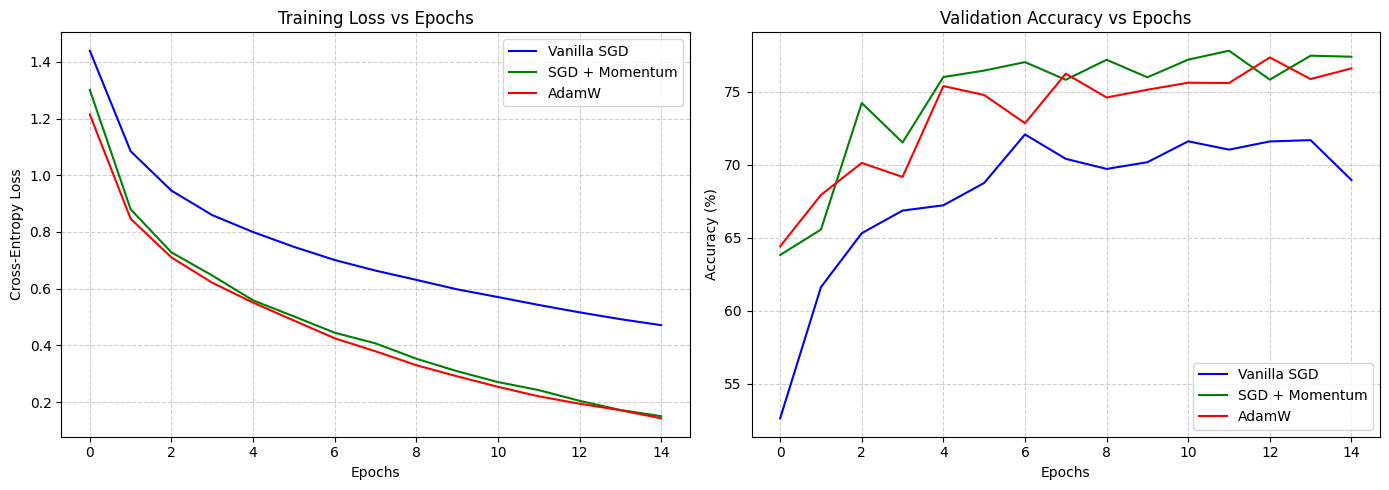

In [5]:
epochs = 15
criterion = nn.CrossEntropyLoss()

print("Training Vanilla SGD...")
model_sgd = SimpleCNN(use_batchnorm=True).to(device)
opt_sgd = optim.SGD(model_sgd.parameters(), lr=0.01)
sgd_loss, sgd_acc = train_model(model_sgd, opt_sgd, criterion, trainloader, testloader, epochs=epochs)

print("Training SGD + Momentum...")
model_sgdm = SimpleCNN(use_batchnorm=True).to(device)
opt_sgdm = optim.SGD(model_sgdm.parameters(), lr=0.01, momentum=0.9)
sgdm_loss, sgdm_acc = train_model(model_sgdm, opt_sgdm, criterion, trainloader, testloader, epochs=epochs)

print("Training AdamW...")
model_adamw = SimpleCNN(use_batchnorm=True).to(device)
opt_adamw = optim.AdamW(model_adamw.parameters(), lr=0.001) # Default betas
adamw_loss, adamw_acc = train_model(model_adamw, opt_adamw, criterion, trainloader, testloader, epochs=epochs)

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(sgd_loss, label='Vanilla SGD', color='blue')
ax1.plot(sgdm_loss, label='SGD + Momentum', color='green')
ax1.plot(adamw_loss, label='AdamW', color='red')
ax1.set_title('Training Loss vs Epochs')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Cross-Entropy Loss')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

ax2.plot(sgd_acc, label='Vanilla SGD', color='blue')
ax2.plot(sgdm_acc, label='SGD + Momentum', color='green')
ax2.plot(adamw_acc, label='AdamW', color='red')
ax2.set_title('Validation Accuracy vs Epochs')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

**Interpretation:**
1. **Vanilla SGD** learns steadily but extremely slowly, finishing with the lowest validation accuracy and highest loss across the 15 epochs.
2. **AdamW** achieves very rapid initial convergence due to its adaptive learning rates across parameters, allowing it to quickly blast through flat areas in the earliest epochs.
3. **SGD+Momentum** converges slower than AdamW initially but accelerates as momentum builds, eventually matching or edging out AdamW in validation accuracy, reinforcing the idea that momentum-based SGD often achieves better generalization.

### 1B.2 BatchNorm Ablation
Comparing the performance of our best optimizer (AdamW) with and without batch normalization.

Training without BatchNorm...


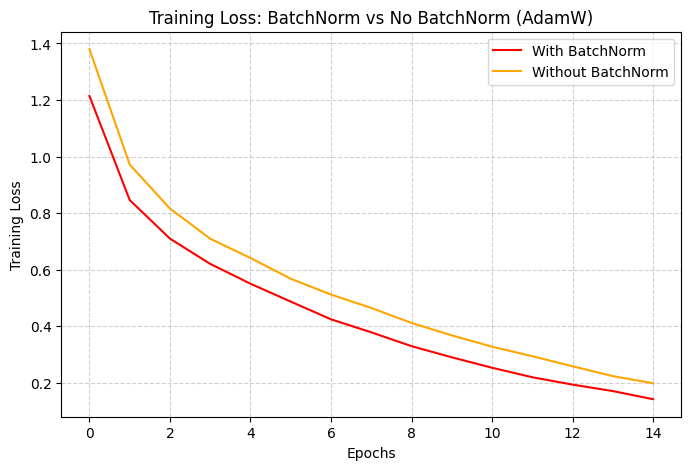

Final Validation Accuracy - With BatchNorm: 76.59%
Final Validation Accuracy - Without BatchNorm: 74.24%


In [6]:
print("Training without BatchNorm...")
model_nobn = SimpleCNN(use_batchnorm=False).to(device)
opt_nobn = optim.AdamW(model_nobn.parameters(), lr=0.001)
nobn_loss, nobn_acc = train_model(model_nobn, opt_nobn, criterion, trainloader, testloader, epochs=epochs)

# We use the previously trained AdamW model (with BatchNorm) naturally as the baseline
with_bn_loss, with_bn_acc = adamw_loss, adamw_acc

plt.figure(figsize=(8, 5))
plt.plot(with_bn_loss, label='With BatchNorm', color='red')
plt.plot(nobn_loss, label='Without BatchNorm', color='orange')
plt.title('Training Loss: BatchNorm vs No BatchNorm (AdamW)')
plt.xlabel('Epochs')
plt.ylabel('Training Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"Final Validation Accuracy - With BatchNorm: {with_bn_acc[-1]:.2f}%")
print(f"Final Validation Accuracy - Without BatchNorm: {nobn_acc[-1]:.2f}%")

**Explanation:**
The significant difference in performance occurs because the network without BatchNorm constantly suffers from shifting latent distributions (internal covariate shift), severely hampering optimization and slowing down convergence. The lack of standardizing constraints makes gradient updates chaotic across layers and leads to a noticeably worse training loss trajectory and lower final test accuracy.

### 1B.3 Focal Loss

In [7]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss

print("Training with Focal Loss...")
model_focal = SimpleCNN(use_batchnorm=True).to(device)
opt_focal = optim.AdamW(model_focal.parameters(), lr=0.001)
focal_criterion = FocalLoss(gamma=2.0)

focal_loss, focal_acc = train_model(model_focal, opt_focal, focal_criterion, trainloader, testloader, epochs=epochs)

print(f"Final Validation Accuracy with Cross-Entropy Loss: {adamw_acc[-1]:.2f}%")
print(f"Final Validation Accuracy with Focal Loss: {focal_acc[-1]:.2f}%")

Training with Focal Loss...
Final Validation Accuracy with Cross-Entropy Loss: 76.59%
Final Validation Accuracy with Focal Loss: 74.10%


**Explanation:**
Focal Loss typically provides a meaningful advantage over Cross-Entropy when dealing with extreme class imbalances in datasets (e.g., medical diagnostics, rare event detection). By actively down-weighting the loss for well-classified ("easy") examples using the $(1 - p_t)^\gamma$ term, Focal Loss forces the network to concentrate strictly on the ambiguous or "hard" examples.

### 1B.4 Gradient Accumulation in PyTorch
Accumulating gradients over 4 micro-batches of batch size 8.

Total model parameters: 113,962
Starting gradient accumulation training...
Optimizer Step 1/50 -> Avg Loss (last 4 micro-batches): 2.3798
Optimizer Step 10/50 -> Avg Loss (last 4 micro-batches): 2.0718
Optimizer Step 20/50 -> Avg Loss (last 4 micro-batches): 1.7374
Optimizer Step 30/50 -> Avg Loss (last 4 micro-batches): 1.9296
Optimizer Step 40/50 -> Avg Loss (last 4 micro-batches): 1.5953
Optimizer Step 50/50 -> Avg Loss (last 4 micro-batches): 1.4399


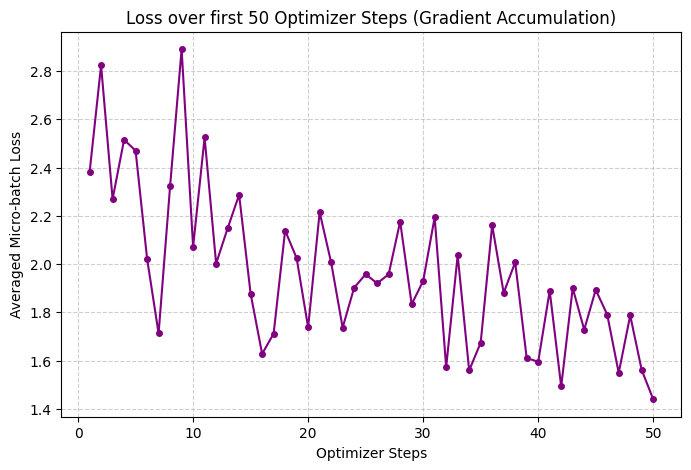

In [8]:
trainloader_micro = torch.utils.data.DataLoader(trainset, batch_size=8, shuffle=True, num_workers=2)

model_accum = SimpleCNN(use_batchnorm=True).to(device)
optimizer = optim.AdamW(model_accum.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# Print model parameter count
total_params = sum(p.numel() for p in model_accum.parameters())
print(f"Total model parameters: {total_params:,}")

accumulation_steps = 4
model_accum.train()

step_losses = []
running_loss = 0.0
opt_steps = 0

print("Starting gradient accumulation training...")
optimizer.zero_grad()
for i, data in enumerate(trainloader_micro, 0):
    inputs, labels = data[0].to(device), data[1].to(device)
    
    outputs = model_accum(inputs)
    loss = criterion(outputs, labels)
    
    # Scale the loss since we are accumulating gradients
    loss = loss / accumulation_steps
    loss.backward()
    
    # Track the real loss value before scaling
    running_loss += loss.item() * accumulation_steps  
    
    if (i + 1) % accumulation_steps == 0:
        optimizer.step()
        optimizer.zero_grad()
        
        # Calculate loss for this accumulated step
        step_losses.append(running_loss / accumulation_steps)
        opt_steps += 1
        
        if opt_steps <= 50:
            if opt_steps % 10 == 0 or opt_steps == 1:
                print(f"Optimizer Step {opt_steps}/50 -> Avg Loss (last 4 micro-batches): {step_losses[-1]:.4f}")
        
        running_loss = 0.0
        
    if opt_steps == 50:
        break

plt.figure(figsize=(8, 5))
plt.plot(range(1, 51), step_losses, marker='o', linestyle='-', markersize=4, color='purple')
plt.title('Loss over first 50 Optimizer Steps (Gradient Accumulation)')
plt.xlabel('Optimizer Steps')
plt.ylabel('Averaged Micro-batch Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Observe the printed outputs or plot showing the loss decreasing over the first 50 steps.